<a href="https://colab.research.google.com/github/VijayReddy-07/Task-3-Mini-Exploratory-Data-Analysis/blob/main/Task_3_Mini_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET

In [2]:
import pandas as pd
df = pd.read_csv('Titanic-Dataset.csv')
print("Dataset Loaded Successfully!\n")
print(df.head())

Dataset Loaded Successfully!

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37345

# DATA EXPLORATION

In [3]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(891, 12)


In [4]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# DATA CLEANING

In [7]:
# Fill missing Age with Mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_3853/1873236825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [8]:
# Fill missing Embarked
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_3853/1851820009.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [10]:
# Drop Cabin Column
df.drop(columns=['Cabin'], inplace=True, errors='ignore')
print("\nMissing Values After Cleaning")
print(df.isnull().sum())



Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# CREATE FAMILY SIZE

In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# QUESTION 1
# Survival Rate by Age Group

In [14]:
import numpy as np
bins = [0, 12, 18, 60, np.inf]
labels = ['Child', 'Teenager', 'Adult', 'Elderly']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_group_survival = df.groupby('AgeGroup')['Survived'].mean()*100

print("\nSurvival Rate by Age Group")
print(age_group_survival)


Survival Rate by Age Group
AgeGroup
Child       57.352941
Teenager    48.888889
Adult       36.436170
Elderly     26.923077
Name: Survived, dtype: float64


/tmp/ipykernel_3853/2370831213.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = df.groupby('AgeGroup')['Survived'].mean()*100


# QUESTION 2
# Survival by Embarkation Port

In [15]:
embarked_survival = df.groupby('Embarked')['Survived'].mean()*100

print("\nSurvival Rate by Embarkation Port")
print(embarked_survival)



Survival Rate by Embarkation Port
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


# QUESTION 3
# Survival by Family Size

In [16]:
family_survival = df.groupby('FamilySize')['Survived'].mean()*100

print("\nSurvival Rate by Family Size")
print(family_survival)


Survival Rate by Family Size
FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


# VISUALIZATION 1
# AGE DISTRIBUTION

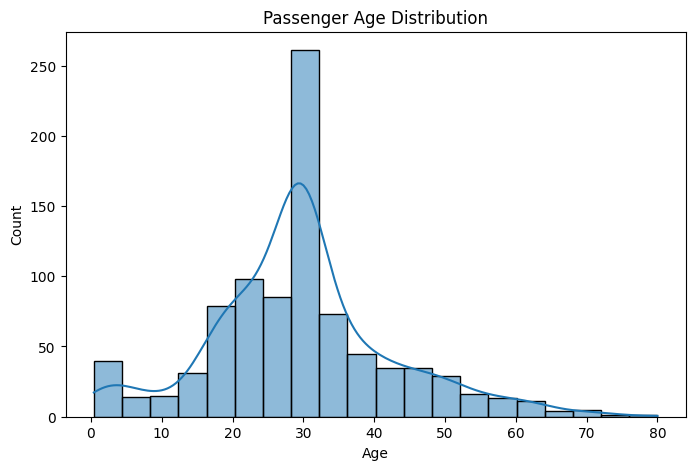

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# VISUALIZATION 2
# CORRELATION HEATMAP

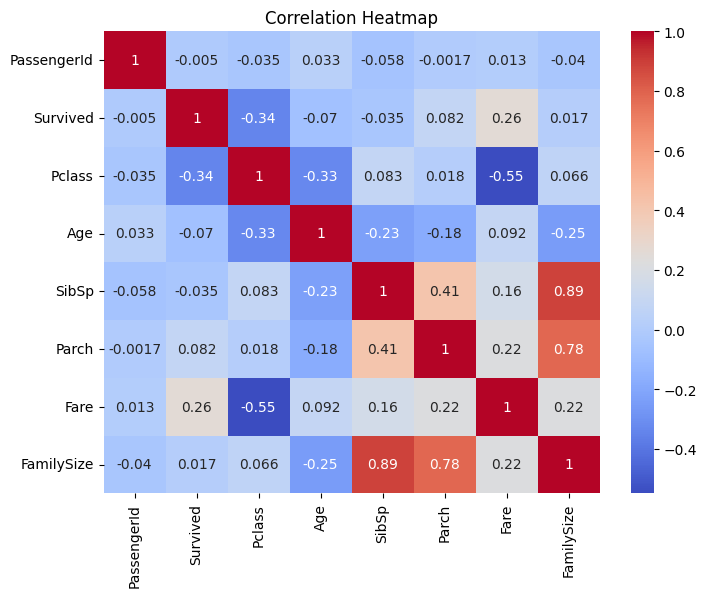

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# VISUALIZATION 3
# SURVIVAL BY FAMILY SIZE

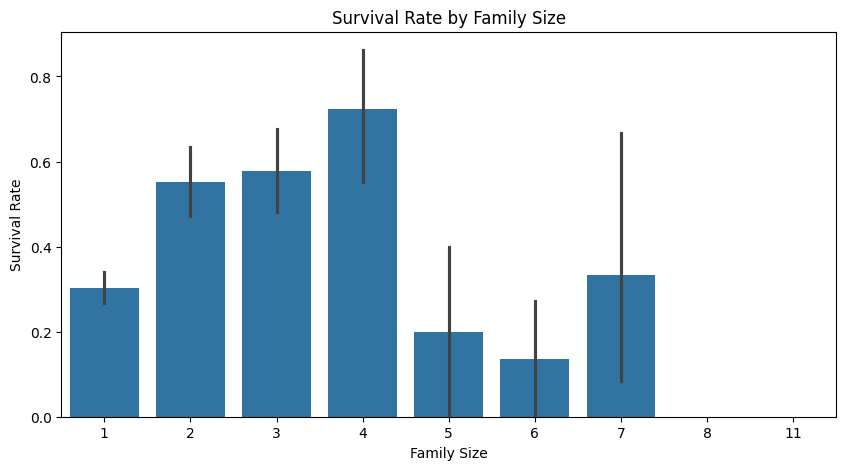

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(x='FamilySize',
            y='Survived',
            data=df)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

# EXTRA VISUALIZATION
# SURVIVAL BY AGE GROUP

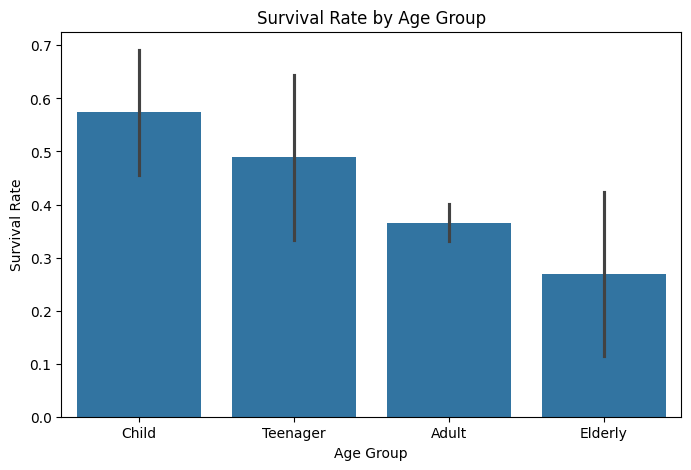

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup',
            y='Survived',
            data=df)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

# EXTRA VISUALIZATION
# SURVIVAL BY EMBARKATION PORT

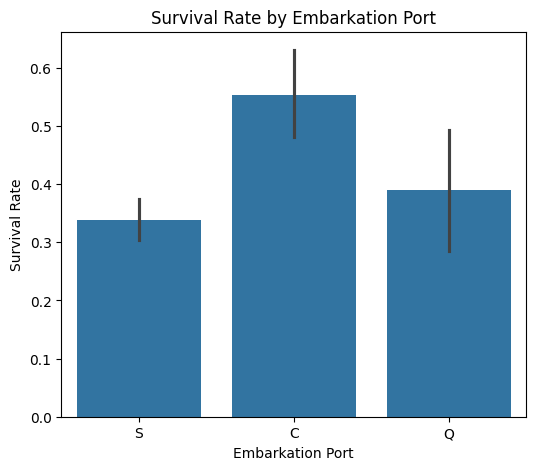

In [22]:
plt.figure(figsize=(6,5))
sns.barplot(x='Embarked',
            y='Survived',
            data=df)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")
plt.show()


# FINAL SUMMARY

In [23]:
print("\n========== TASK 3 SUMMARY ==========")

print("\nAge Group Survival")
print(age_group_survival)

print("\nEmbarkation Port Survival")
print(embarked_survival)

print("\nFamily Size Survival")
print(family_survival)

print("\nEDA Completed Successfully!")


========== TASK 3 SUMMARY ==========

Age Group Survival
AgeGroup
Child       57.352941
Teenager    48.888889
Adult       36.436170
Elderly     26.923077
Name: Survived, dtype: float64

Embarkation Port Survival
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

Family Size Survival
FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

EDA Completed Successfully!
